In [8]:
import os
import torch
import numpy as np
import cv2
import xml.etree.ElementTree as ET
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models.detection import keypointrcnn_resnet50_fpn, KeypointRCNN_ResNet50_FPN_Weights
from decord import VideoReader, cpu

# --- Configuration ---
CONFIG = {
    'videos_root': r'H:\DPJI\data\IDDPedestrian\videos\gopro',
    'ped_xml_root': r'H:\DPJI\data\IDDPedestrian\annotations\gopro',
    'veh_xml_root': r'H:\DPJI\data\IDDPedestrian\annotations_vehicle\gopro',
    
    'img_size': (224, 224),
    'seq_len': 16,      
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"✅ Configuration Loaded. Device: {CONFIG['device']}")

✅ Configuration Loaded. Device: cuda


In [9]:
def load_pose_model():
    print(f"Initializing ResNet-50 Keypoint R-CNN on {CONFIG['device']}...")
    weights = KeypointRCNN_ResNet50_FPN_Weights.DEFAULT
    model = keypointrcnn_resnet50_fpn(weights=weights, progress=False)
    model.to(CONFIG['device'])
    model.eval()
    print("✅ Success: Pose Model Loaded.")
    return model

pose_model = load_pose_model()

Initializing ResNet-50 Keypoint R-CNN on cuda...
✅ Success: Pose Model Loaded.


In [10]:
import xml.etree.ElementTree as ET

def parse_idd_metadata(video_file, ped_xml, veh_xml):
    samples = []
    
    # --- 1. Context: Traffic Lights ---
    tl_context = {} 
    if os.path.exists(veh_xml):
        try:
            v_root = ET.parse(veh_xml).getroot()
            for track in v_root.findall('track'):
                if track.attrib['label'] == 'traffic_light':
                    for box in track.findall('box'):
                        tl_context[int(box.attrib['frame'])] = box.attrib.get('traffic_light_state', 'none')
        except: pass

    if not os.path.exists(ped_xml): return []
    
    try:
        tree = ET.parse(ped_xml)
        p_root = tree.getroot()
        
        # --- Task 1.c: Scene Attributes ---
        scene_meta = {
            'time_of_day': p_root.findtext(".//attribute[@name='timeofday']", "day"),
            'intersection': p_root.findtext(".//attribute[@name='intersection']", "NI"),
            'signalized': p_root.findtext(".//attribute[@name='signalized']", "N/A")
        }

        # Helper to check multiple attribute names
        def get_attr(box_element, names_list, default="n/a"):
            val = None
            if isinstance(names_list, str): names_list = [names_list]
            
            # Check each possible name (e.g., check 'CB' then 'behavior')
            for name in names_list:
                val = box_element.findtext(f"attribute[@name='{name}']")
                if not val: 
                    val = box_element.attrib.get(name)
                if val: break
            
            return val.lower().strip() if val else default

        # --- UPDATED CROSSING DEFINITION ---
        TARGET_CROSSING_BEHAVIORS = {
            'cu', 'crossing_undesignated',
            'cd', 'crossing_designated',
            'ci', 'crossing_irrelevant',
            'cfu', 'crossing_fast_undesignated',
            'cfd', 'crossing_fast_designated'
        }
        
        for track in p_root.findall('track'):
            if track.attrib['label'] != 'pedestrian': continue
            
            for box in track.findall('box'):
                if box.attrib.get('occlusion', '0') == '2': continue 
                
                # --- BEHAVIOR EXTRACTION (The Fix) ---
                # Priority: 'CB' (Short code), then 'behavior', then 'crossing_behavior'
                beh = get_attr(box, ['CB', 'behavior', 'crossing_behavior'], 'n/a')
                
                # --- LABEL ASSIGNMENT ---
                # 1. Check explicit crossing flag (if available)
                crossing_flag = get_attr(box, 'crossing', 'n/a')
                
                if crossing_flag in ['1', 'yes', 'true']:
                    label = 1.0
                elif crossing_flag in ['0', 'no', 'false']:
                    label = 0.0
                else:
                    # 2. Fallback to Behavior Code (CB)
                    label = 1.0 if beh in TARGET_CROSSING_BEHAVIORS else 0.0

                bbox = [float(box.attrib[k]) for k in ['xtl', 'ytl', 'xbr', 'ybr']]
                frame_id = int(box.attrib['frame'])
                
                # Extract other short-code attributes
                meta_dict = {
                    'behavior_code': beh,
                    'age': get_attr(track, 'age', 'adult'),
                    'gender': get_attr(track, 'gender', 'default'),
                    'attention': get_attr(box, ['AI', 'attention'], 'n/a'),
                    'traffic_interaction': get_attr(box, ['TI', 'traffic_interaction'], 'n/a'),
                    'activity': get_attr(box, ['PA', 'pedestrian_activity'], 'n/a'),
                    **scene_meta
                }

                samples.append({
                    'video_path': video_file,
                    'frame': frame_id,
                    'bbox': bbox,
                    'label': label,
                    'tl_state': tl_context.get(frame_id, 'none'),
                    'metadata': meta_dict
                })
                
    except Exception as e:
        print(f"Error parsing {ped_xml}: {e}")
        
    return samples

In [11]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from decord import VideoReader, cpu
import cv2
import numpy as np
import torch
import os

class IDDPedDataset(Dataset):
    def __init__(self, config, pose_model, transform=None):
        self.config = config
        self.pose_model = pose_model
        self.transform = transform
        self.data = []
        
        root_vid = config['videos_root']
        root_ped = config['ped_xml_root']
        root_veh = config['veh_xml_root']
        
        if not os.path.exists(root_vid):
            raise FileNotFoundError(f"Root path not found: {root_vid}")
            
        sets = [d for d in os.listdir(root_vid) if os.path.isdir(os.path.join(root_vid, d))]
        print(f"📂 Found {len(sets)} sets: {sets}")
        
        for set_name in sets:
            vid_dir = os.path.join(root_vid, set_name)
            # Filter out hidden files
            vids = [v for v in os.listdir(vid_dir) if v.lower().endswith('.mp4') and not v.startswith('._')]
            
            for v in vids:
                v_name = os.path.splitext(v)[0]
                full_vid_path = os.path.join(vid_dir, v)
                
                p_xml = os.path.join(root_ped, set_name, v_name + '.xml')
                v_xml = os.path.join(root_veh, set_name, v_name + '_obd.xml')
                
                if os.path.exists(p_xml):
                    self.data.extend(parse_idd_metadata(full_vid_path, p_xml, v_xml))
                
        print(f"✅ Total Dataset Ready: {len(self.data)} samples loaded.")

    def __len__(self):
        return len(self.data)

    def _get_pose_torchvision(self, frame_tensor, bbox):
        with torch.no_grad():
            predictions = self.pose_model([frame_tensor.to(self.config['device'])])[0]
        
        kps = predictions['keypoints'].cpu().numpy()
        scores = predictions['scores'].cpu().numpy()
        boxes = predictions['boxes'].cpu().numpy()
        
        if len(scores) == 0: return np.zeros((17, 3))
            
        x1, y1, x2, y2 = bbox
        gt_center = np.array([(x1+x2)/2, (y1+y2)/2])
        best_idx = -1
        min_dist = float('inf')
        
        for i, box in enumerate(boxes):
            if scores[i] < 0.3: continue
            box_center = np.array([(box[0]+box[2])/2, (box[1]+box[3])/2])
            dist = np.linalg.norm(gt_center - box_center)
            if dist < min_dist:
                min_dist = dist
                best_idx = i
        
        return kps[best_idx] if best_idx != -1 else np.zeros((17, 3))

    def __getitem__(self, idx):
        meta = self.data[idx]
        try:
            vr = VideoReader(meta['video_path'], ctx=cpu(0))
        except Exception:
            return self._dummy_sample()

        indices = [max(0, meta['frame'] - i) for i in range(self.config['seq_len'])][::-1]
        frames = vr.get_batch(indices).asnumpy()
        
        tensors = []
        poses = []
        x1, y1, x2, y2 = map(int, meta['bbox'])
        
        for frame in frames:
            frame_tensor = torch.from_numpy(frame).permute(2, 0, 1).float() / 255.0
            kps = self._get_pose_torchvision(frame_tensor, [x1, y1, x2, y2])
            poses.append(kps)
            
            h, w, _ = frame.shape
            crop = frame[max(0,y1):min(h,y2), max(0,x1):min(w,x2)]
            
            if crop.size == 0: crop = np.zeros((224, 224, 3), dtype=np.uint8)
            else: crop = cv2.resize(crop, self.config['img_size'])
                
            crop_tensor = torch.from_numpy(crop).permute(2, 0, 1).float() / 255.0
            if self.transform: crop_tensor = self.transform(crop_tensor)
            tensors.append(crop_tensor)

        return {
            'images': torch.stack(tensors),
            'poses': torch.tensor(np.array(poses)).float(),
            'label': torch.tensor(meta['label']).float(),
            'behavior': meta['metadata']['behavior_code']
        }

    def _dummy_sample(self):
        return {
            'images': torch.zeros((self.config['seq_len'], 3, 224, 224)),
            'poses': torch.zeros((self.config['seq_len'], 17, 3)),
            'label': torch.tensor(0.0),
            'behavior': 'n/a'
        }

In [12]:
tfm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

print("Initializing Dataset (Checking 'CB' and 'behavior' attributes)...")
dataset = IDDPedDataset(CONFIG, pose_model, transform=tfm)

if len(dataset) > 0:
    loader = DataLoader(dataset, batch_size=2, shuffle=True)
    print("\n--- Testing Pipeline ---")
    for batch in loader:
        print(f"Images: {batch['images'].shape}")
        print(f"Label:  {batch['label']}")
        print(f"Behav:  {batch['behavior']}")
        break
else:
    print("❌ Dataset empty.")

Initializing Dataset (Checking 'CB' and 'behavior' attributes)...
📂 Found 9 sets: ['gp_set_0001', 'gp_set_0002', 'gp_set_0003', 'gp_set_0009', 'gp_set_0004', 'gp_set_0005', 'gp_set_0006', 'gp_set_0007', 'gp_set_0008']
✅ Total Dataset Ready: 504844 samples loaded.

--- Testing Pipeline ---
Images: torch.Size([2, 16, 3, 224, 224])
Label:  tensor([0., 0.])
Behav:  ['n/a', 'n/a']


In [13]:
import matplotlib.pyplot as plt
from collections import Counter

def check_final_balance(dataset_obj):
    if not hasattr(dataset_obj, 'data') or len(dataset_obj) == 0:
        print("❌ Dataset is empty.")
        return

    print(f"📊 Analyzing {len(dataset_obj)} samples...")
    
    # 1. Labels
    labels = [sample['label'] for sample in dataset_obj.data]
    crossing = int(sum(labels))
    no_crossing = len(labels) - crossing
    
    # 2. Behaviors
    behaviors = [sample['metadata']['behavior_code'] for sample in dataset_obj.data]
    beh_counts = Counter(behaviors)
    
    print("\n" + "="*40)
    print("      FINAL DATASET BALANCE      ")
    print("="*40)
    print(f"✅ CROSSING (Label 1):     {crossing}  ({(crossing/len(labels))*100:.1f}%)")
    print(f"   (Sources: 'CB' attribute -> CU, CD, CI, CFU, CFD)")
    print("-" * 40)
    print(f"❌ NO CROSSING (Label 0):  {no_crossing}  ({(no_crossing/len(labels))*100:.1f}%)")
    print("="*40)
    
    print("\nDetailed Behavior Counts (Top 10):")
    for b, c in beh_counts.most_common(10):
        print(f" - {b.upper()}: {c}")

check_final_balance(dataset)

📊 Analyzing 504844 samples...

      FINAL DATASET BALANCE      
✅ CROSSING (Label 1):     136441  (27.0%)
   (Sources: 'CB' attribute -> CU, CD, CI, CFU, CFD)
----------------------------------------
❌ NO CROSSING (Label 0):  368403  (73.0%)

Detailed Behavior Counts (Top 10):
 - N/A: 368403
 - CU: 101155
 - CD: 27074
 - CI: 4777
 - CFU: 2933
 - CFD: 502


In [14]:
import os
import xml.etree.ElementTree as ET
from collections import Counter

def run_behavior_diagnostic_cb(config):
    root_ped = config['ped_xml_root']
    target_codes = ['CU', 'CD', 'CI', 'CFU', 'CFD']
    found_targets = {code: 0 for code in target_codes}
    all_raw_behaviors = Counter()
    
    print(f"🔍 Scanning XMLs in: {root_ped} ...")
    
    for root, dirs, files in os.walk(root_ped):
        for file in files:
            if file.endswith('.xml') and not file.startswith('._'):
                xml_path = os.path.join(root, file)
                try:
                    tree = ET.parse(xml_path)
                    for track in tree.getroot().findall('track'):
                        if track.attrib['label'] != 'pedestrian': continue
                        for box in track.findall('box'):
                            # CHECK FOR 'CB' FIRST (Critical Update)
                            beh_raw = box.findtext("attribute[@name='CB']")
                            if not beh_raw: beh_raw = box.findtext("attribute[@name='behavior']")
                            if not beh_raw: beh_raw = box.attrib.get('behavior')
                                
                            if beh_raw:
                                clean = beh_raw.strip().upper()
                                if clean in target_codes:
                                    found_targets[clean] += 1
                                all_raw_behaviors[clean] += 1
                except: pass

    print("="*40)
    print("      TARGET CODE COUNTS (Checking 'CB')      ")
    print("="*40)
    for code in target_codes:
        print(f"✅ {code}: {found_targets[code]}")

run_behavior_diagnostic_cb(CONFIG)

🔍 Scanning XMLs in: H:\DPJI\data\IDDPedestrian\annotations\gopro ...
      TARGET CODE COUNTS (Checking 'CB')      
✅ CU: 101155
✅ CD: 27074
✅ CI: 4777
✅ CFU: 2933
✅ CFD: 502


# Task2

📊 Scanning ALL Annotation Folders for Occlusion Levels...
   Found 67 XML files. Parsing...


100%|████████████████████████████████████████████████████████████████████████| 67/67 [00:43<00:00,  1.54it/s]
H:\DPJI\my_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
H:\DPJI\my_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
H:\DPJI\my_env\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
H:\DPJI\my_env\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray

✅ Statistics Ready. (Day: 45, Night: 22)


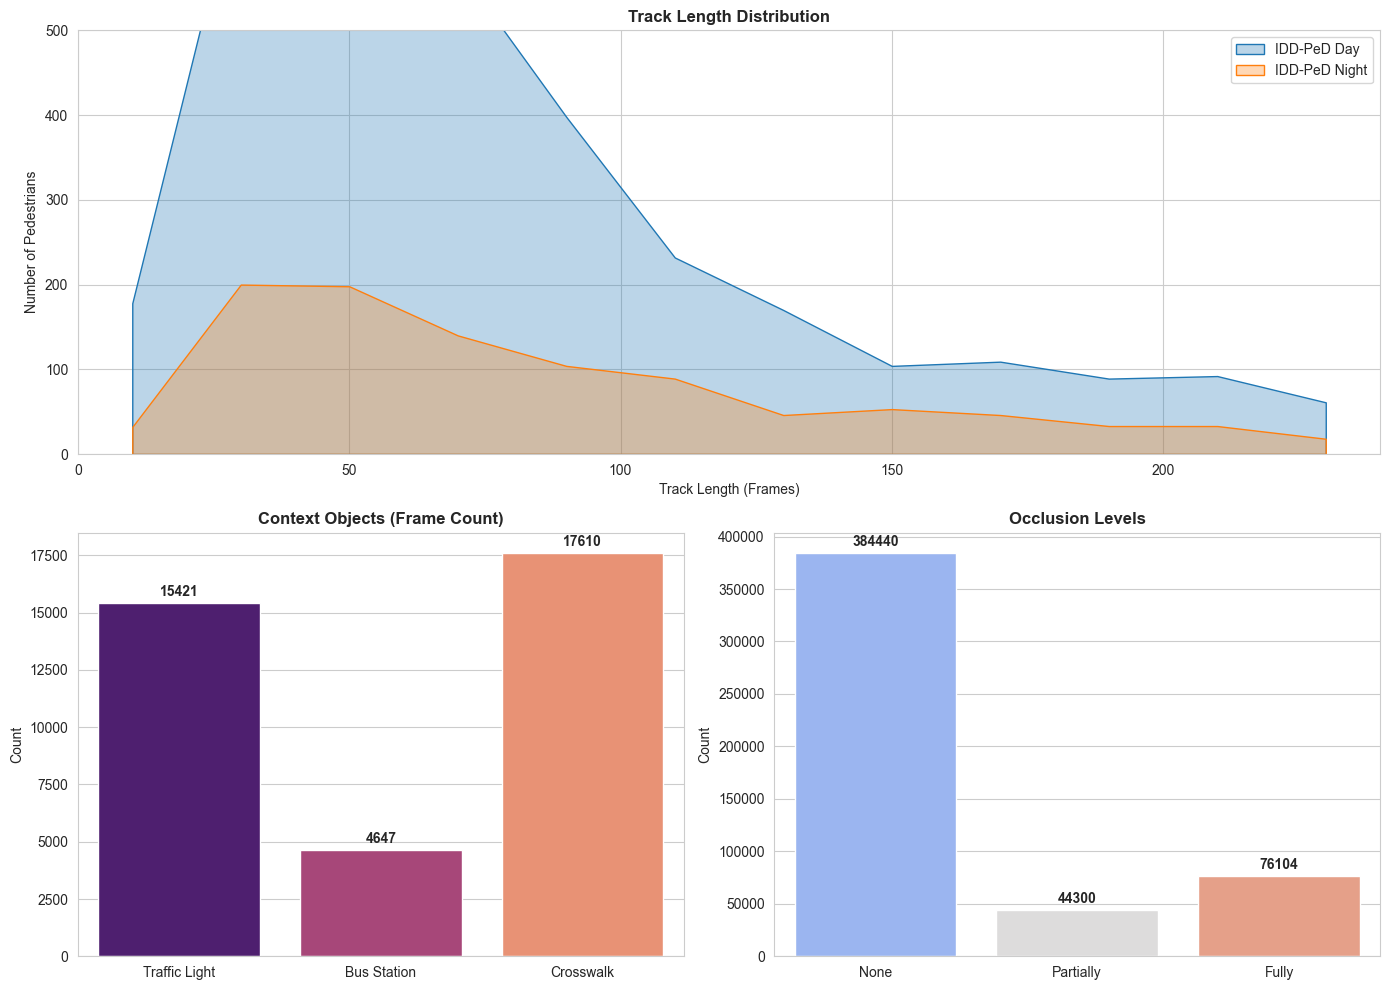

In [31]:
import os
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm

# --- Configuration Check ---
if 'CONFIG' not in locals():
    print("⚠️ CONFIG not found. Please run Task 1 Cell 1 first.")

# --- 1. MANUAL DAY/NIGHT CLASSIFICATION ---
NIGHT_VIDEOS = {
    "gp_set_0001_vid_0001", "gp_set_0001_vid_0002", "gp_set_0001_vid_0003", "gp_set_0001_vid_0004",
    "gp_set_0002_vid_0002",
    "gp_set_0003_vid_0005",
    "gp_set_0004_vid_0005",
    "gp_set_0005_vid_0005",
    "gp_set_0007_vid_0001", "gp_set_0007_vid_0002", "gp_set_0007_vid_0003", "gp_set_0007_vid_0004",
    "gp_set_0008_vid_0001", "gp_set_0008_vid_0002", "gp_set_0008_vid_0003", "gp_set_0008_vid_0004", "gp_set_0008_vid_0005"
}

def collect_edd_stats(config):
    stats = {
        'track_lengths': {'day': [], 'night': []},
        'objects': {'Traffic Light': 0, 'Bus Station': 0, 'Crosswalk': 0},
        'occlusion': {'None': 0, 'Partially': 0, 'Fully': 0}
    }
    
    roots_to_scan = [config['ped_xml_root'], config['veh_xml_root']]
    
    print("📊 Scanning ALL Annotation Folders for Occlusion Levels...")
    xml_files = []
    for root_dir in roots_to_scan:
        if not os.path.exists(root_dir): continue
        for root, dirs, files in os.walk(root_dir):
            for file in files:
                if file.endswith('.xml') and not file.startswith('._'):
                    xml_files.append(os.path.join(root, file))
                
    print(f"   Found {len(xml_files)} XML files. Parsing...")

    count_day = 0
    count_night = 0

    for xml_path in tqdm(xml_files):
        try:
            tree = ET.parse(xml_path)
            root = tree.getroot()
            
            # --- Determine Day/Night ---
            file_id = os.path.splitext(os.path.basename(xml_path))[0]
            clean_id = file_id.replace('_obd', '')
            
            if clean_id in NIGHT_VIDEOS:
                is_day = False
                count_night += 1
            else:
                is_day = True
                count_day += 1
            
            # --- Parse Tracks ---
            for track in root.findall('track'):
                label = track.attrib['label']
                boxes = track.findall('box')
                
                # 1. Pedestrian Stats
                if label == 'pedestrian':
                    duration = len(boxes)
                    if is_day: stats['track_lengths']['day'].append(duration)
                    else: stats['track_lengths']['night'].append(duration)
                    
                    for box in boxes:
                        # --- SMART OCCLUSION FINDER ---
                        candidates = []
                        
                        # A. Check Sub-attributes
                        for attr in box.findall('attribute'):
                            name = attr.get('name', '').lower()
                            if name in ['occlusion', 'occlusion_level', 'occluded']:
                                if attr.text: candidates.append(attr.text.strip().lower())

                        # B. Check Box Attributes
                        if box.attrib.get('occlusion'): candidates.append(box.attrib.get('occlusion').strip().lower())
                        if box.attrib.get('occluded'): candidates.append(box.attrib.get('occluded').strip().lower())

                        # --- DECISION LOGIC ---
                        # We prioritize explicit levels (2/Fully, 1/Partially) over binary flags
                        final_occ = 'none' # Default
                        
                        if any(c in ['2', 'fully', 'full'] for c in candidates):
                            final_occ = 'fully'
                        elif any(c in ['1', 'partially', 'partial', 'part'] for c in candidates):
                            final_occ = 'partially'
                        elif any(c in ['0', 'none', 'no', 'false'] for c in candidates):
                            final_occ = 'none'
                        
                        # Map to Stats
                        if final_occ == 'fully': stats['occlusion']['Fully'] += 1
                        elif final_occ == 'partially': stats['occlusion']['Partially'] += 1
                        elif final_occ == 'none': stats['occlusion']['None'] += 1

                # 2. Context Objects
                elif label == 'traffic_light':
                    stats['objects']['Traffic Light'] += len(boxes)
                elif label == 'bus_station':
                    stats['objects']['Bus Station'] += len(boxes)
                elif label == 'crosswalk':
                    stats['objects']['Crosswalk'] += len(boxes)

        except Exception as e:
            pass 

    print(f"✅ Statistics Ready. (Day: {count_day}, Night: {count_night})")
    return stats

# --- Run Collection ---
raw_stats = collect_edd_stats(CONFIG)

# --- Generate Plot ---
try:
    sns.set_style("whitegrid")
    
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(2, 2)
    
    ax_track = fig.add_subplot(gs[0, :]) # Top row
    ax_ctx = fig.add_subplot(gs[1, 0])   # Bottom left
    ax_occ = fig.add_subplot(gs[1, 1])   # Bottom right
    
    # 1. Track Lengths (Top)
    sns.histplot(raw_stats['track_lengths']['day'], color='#1f77b4', label='IDD-PeD Day', 
                 ax=ax_track, element="poly", fill=True, alpha=0.3, binwidth=20, binrange=(0,240))
    sns.histplot(raw_stats['track_lengths']['night'], color='#ff7f0e', label='IDD-PeD Night', 
                 ax=ax_track, element="poly", fill=True, alpha=0.3, binwidth=20, binrange=(0,240))
    
    ax_track.set_title('Track Length Distribution', fontweight='bold', fontsize=12)
    ax_track.set_xlabel('Track Length (Frames)')
    ax_track.set_ylabel('Number of Pedestrians')
    ax_track.set_xlim(0, 240)
    ax_track.set_ylim(0, 500)
    ax_track.legend(loc='upper right')
    
    # 2. Context Objects (Bottom Left)
    o_names = list(raw_stats['objects'].keys())
    o_vals = list(raw_stats['objects'].values())
    
    sns.barplot(x=o_names, y=o_vals, ax=ax_ctx, palette='magma')
    ax_ctx.set_title('Context Objects (Frame Count)', fontweight='bold', fontsize=12)
    ax_ctx.set_ylabel('Count')
    for i, v in enumerate(o_vals):
        ax_ctx.text(i, v + (max(o_vals)*0.01), str(v), ha='center', va='bottom', fontweight='bold')

    # 3. Occlusion Levels (Bottom Right)
    occ_names = list(raw_stats['occlusion'].keys())
    occ_vals = list(raw_stats['occlusion'].values())
    
    sns.barplot(x=occ_names, y=occ_vals, ax=ax_occ, palette='coolwarm')
    ax_occ.set_title('Occlusion Levels', fontweight='bold', fontsize=12)
    ax_occ.set_ylabel('Count')
    for i, v in enumerate(occ_vals):
        offset = (max(occ_vals)*0.01) if len(occ_vals) > 0 and max(occ_vals) > 0 else 0
        ax_occ.text(i, v + offset, str(v), ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Visualization skipped: {e}")

📊 Scanning ALL XMLs (Pedestrian & Vehicle) for Attributes...
   Found 67 files. Extracting frames...


100%|████████████████████████████████████████████████████████████████████████| 67/67 [00:43<00:00,  1.55it/s]


✅ Data Collection Complete.


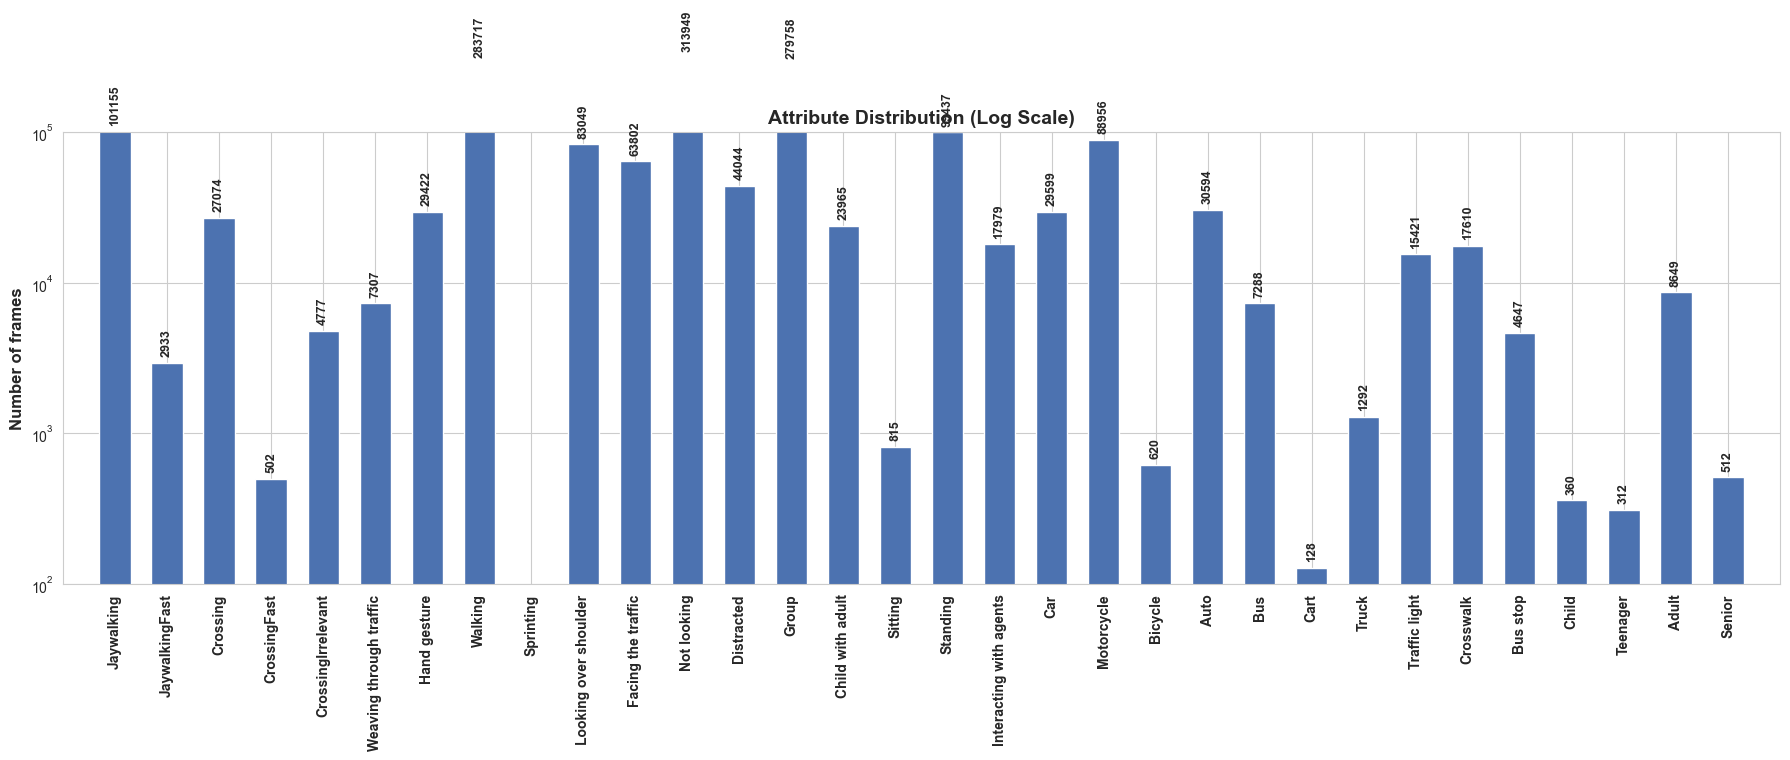

In [37]:
import os
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm

# --- Configuration Check ---
if 'CONFIG' not in locals():
    print("⚠️ CONFIG not found. Please run Task 1 Cell 1 first.")

def collect_comprehensive_stats(config):
    # 1. Initialize Counts
    categories = {
        # Crossing
        'Jaywalking': 0, 'JaywalkingFast': 0, 'Crossing': 0, 'CrossingFast': 0, 'CrossingIrrelevant': 0,
        # Interaction
        'Weaving through traffic': 0, 'Hand gesture': 0,
        # Activity
        'Walking': 0, 'Sprinting': 0,
        # Attention
        'Looking over shoulder': 0, 'Facing the traffic': 0, 'Not looking': 0, 'Distracted': 0,
        # Social
        'Group': 0, 'Child with adult': 0,
        # Stationary
        'Sitting': 0, 'Standing': 0, 'Interacting with agents': 0,
        # Vehicles
        'Car': 0, 'Motorcycle': 0, 'Bicycle': 0, 'Auto': 0, 'Bus': 0, 'Cart': 0, 'Truck': 0,
        # Context
        'Traffic light': 0, 'Crosswalk': 0, 'Bus stop': 0,
        # Demographics
        'Child': 0, 'Teenager': 0, 'Adult': 0, 'Senior': 0
    }

    # 2. Universal Mapping (Lowercase -> Category)
    VALUE_MAP = {
        # --- PEDESTRIAN ACTIVITY (PA) ---
        'sprinting': 'Sprinting', 'sprint': 'Sprinting', 
        'moves fast': 'Sprinting', 'moving fast': 'Sprinting', 
        'fast': 'Sprinting', 'running': 'Sprinting', 'run': 'Sprinting',
        'walking': 'Walking', 'walk': 'Walking',
        
        # --- CROSSING BEHAVIOR (CB) ---
        'cu': 'Jaywalking', 'crossing_undesignated': 'Jaywalking',
        'cfu': 'JaywalkingFast', 'crossing_fast_undesignated': 'JaywalkingFast',
        'cd': 'Crossing', 'crossing_designated': 'Crossing',
        'cfd': 'CrossingFast', 'crossing_fast_designated': 'CrossingFast',
        'ci': 'CrossingIrrelevant', 'crossing_irrelevant': 'CrossingIrrelevant',
        
        # --- TRAFFIC INTERACTION (TI) ---
        'wtt': 'Weaving through traffic', 'weaving': 'Weaving through traffic', 'weaving through traffic': 'Weaving through traffic',
        'hg': 'Hand gesture', 'hand_gesture': 'Hand gesture',
        
        # --- ATTENTION (AI) ---
        'los': 'Looking over shoulder', 'looking_over_shoulder': 'Looking over shoulder', 'looking over shoulder': 'Looking over shoulder',
        'ftt': 'Facing the traffic', 'facing_traffic': 'Facing the traffic', 'facing the traffic': 'Facing the traffic',
        'nl': 'Not looking', 'not_looking': 'Not looking', 'not looking': 'Not looking',
        'db': 'Distracted', 'distracted': 'Distracted',
        
        # --- SOCIAL DYNAMICS (SD) ---
        'gs': 'Group', 'group': 'Group',
        'cfa': 'Child with adult', 'child_following_adult': 'Child with adult',
        'awc': 'Child with adult', 'adult_with_child': 'Child with adult', 'child with adult': 'Child with adult',
        
        # --- STATIONARY BEHAVIOR (SB) ---
        'sitting': 'Sitting',
        'standing': 'Standing',
        'iwa': 'Interacting with agents', 'interacting_with_agents': 'Interacting with agents',
        
        # --- DEMOGRAPHICS (AGE) ---
        'child': 'Child',
        'teenager': 'Teenager', 'teen': 'Teenager',
        'adult': 'Adult',
        'senior': 'Senior',
        
        # --- VEHICLES & CONTEXT ---
        'car': 'Car',
        'motorcycle': 'Motorcycle', 'motorbike': 'Motorcycle', 'bike': 'Motorcycle',
        'bicycle': 'Bicycle', 'cycle': 'Bicycle',
        'auto': 'Auto', 'autorickshaw': 'Auto', 'rickshaw': 'Auto',
        'bus': 'Bus',
        'cart': 'Cart',
        'truck': 'Truck',
        'traffic_light': 'Traffic light',
        'crosswalk': 'Crosswalk',
        'bus_station': 'Bus stop', 'bus_stop': 'Bus stop'
    }

    roots_to_scan = [config['ped_xml_root'], config['veh_xml_root']]
    print("📊 Scanning ALL XMLs (Pedestrian & Vehicle) for Attributes...")
    
    xml_files = []
    for root_dir in roots_to_scan:
        if not os.path.exists(root_dir): continue
        for root, dirs, files in os.walk(root_dir):
            for file in files:
                if file.endswith('.xml') and not file.startswith('._'):
                    xml_files.append(os.path.join(root, file))

    print(f"   Found {len(xml_files)} files. Extracting frames...")

    for xml_path in tqdm(xml_files):
        try:
            tree = ET.parse(xml_path)
            root = tree.getroot()
            
            for track in root.findall('track'):
                # Clean label
                label_raw = track.attrib.get('label', '').lower().strip()
                boxes = track.findall('box')
                
                # --- LEVEL 1: TRACK VALUES ---
                track_values = set()
                # Add label itself (e.g., "car")
                if label_raw: track_values.add(label_raw)
                
                # Add track attributes
                for attr in track.findall('attribute'):
                    if attr.text: track_values.add(attr.text.lower().strip())
                for k, v in track.attrib.items():
                    if k != 'label': track_values.add(v.lower().strip())

                # --- LEVEL 2: BOX VALUES (FRAMES) ---
                for box in boxes:
                    current_values = track_values.copy()
                    
                    # Add box attributes
                    for attr in box.findall('attribute'):
                        # Check for Short Codes like PA (Pedestrian Activity)
                        # but we just grab the *value* (e.g. "Sprinting")
                        if attr.text: current_values.add(attr.text.lower().strip())
                            
                    for k, v in box.attrib.items():
                        # Skip numeric/tech attributes
                        if k not in ['xtl', 'ytl', 'xbr', 'ybr', 'frame', 'occluded', 'outside', 'z_order', 'keyframe', 'rotation']:
                            current_values.add(v.lower().strip())

                    # --- MATCH & COUNT ---
                    matched_cats = set()
                    
                    for val in current_values:
                        if val in VALUE_MAP:
                            cat = VALUE_MAP[val]
                            
                            # LOGIC FILTERS
                            # If Track is Pedestrian, don't count it as a Car (unless interacting)
                            # We strictly count behaviors for pedestrians, and types for vehicles.
                            if label_raw == 'pedestrian':
                                # Allowed: Behaviors, Demographics
                                if cat in ['Car', 'Bus', 'Truck', 'Auto', 'Motorcycle', 'Traffic light', 'Crosswalk', 'Bus stop']:
                                    continue
                            elif label_raw in ['car', 'bus', 'truck', 'vehicle', 'auto', 'motorcycle']:
                                # Allowed: Vehicle Types
                                if cat in ['Walking', 'Sprinting', 'Jaywalking', 'JaywalkingFast', 'Crossing', 'Child', 'Adult', 'Senior']:
                                    continue
                            
                            if cat not in matched_cats:
                                categories[cat] += 1
                                matched_cats.add(cat)

        except Exception as e:
            pass
            
    return categories

# --- Run Collection ---
final_counts = collect_comprehensive_stats(CONFIG)
print("✅ Data Collection Complete.")

# --- Visualization ---
order_list = [
    'Jaywalking', 'JaywalkingFast', 'Crossing', 'CrossingFast', 'CrossingIrrelevant',
    'Weaving through traffic', 'Hand gesture',
    'Walking', 'Sprinting',
    'Looking over shoulder', 'Facing the traffic', 'Not looking', 'Distracted',
    'Group', 'Child with adult',
    'Sitting', 'Standing', 'Interacting with agents',
    'Car', 'Motorcycle', 'Bicycle', 'Auto', 'Bus', 'Cart', 'Truck',
    'Traffic light', 'Crosswalk', 'Bus stop',
    'Child', 'Teenager', 'Adult', 'Senior'
]

values = [final_counts[k] for k in order_list]

try:
    plt.figure(figsize=(18, 8))
    sns.set_style("whitegrid")
    
    # Create Bar Plot
    bars = plt.bar(order_list, values, color='#4c72b0', width=0.6)
    
    # Y-Axis (Log Scale)
    plt.yscale('log')
    plt.ylim(100, 100000) 
    plt.ylabel('Number of frames', fontsize=12, fontweight='bold')
    
    # X-Axis
    plt.xticks(rotation=90, fontsize=10, fontweight='bold')
    plt.xlim(-1, len(order_list))
    
    # Add count labels
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(bar.get_x() + bar.get_width()/2., height * 1.1,
                     f'{int(height)}',
                     ha='center', va='bottom', rotation=90, fontsize=9, fontweight='bold')

    plt.title("Attribute Distribution (Log Scale)", fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Plotting error: {e}")

# Task3

In [50]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models.video import r3d_18, R3D_18_Weights

# --- Configuration (Reuse existing) ---
if 'CONFIG' not in locals():
    # Fallback if Task 1 wasn't run in this session
    CONFIG = {'device': 'cuda' if torch.cuda.is_available() else 'cpu'}

# --- 1. Context Encoder (Traffic Lights) ---
class ContextEncoder(nn.Module):
    def __init__(self, embedding_dim=16):
        super().__init__()
        # Map strings to indices
        self.tl_map = {'red': 0, 'green': 1, 'orange': 2, 'none': 3, 'unknown': 3, 'n/a': 3}
        self.embed = nn.Embedding(num_embeddings=4, embedding_dim=embedding_dim)
        
    def forward(self, tl_states_batch):
        # Convert list of strings to tensor indices
        indices = []
        for state in tl_states_batch:
            # Handle if state is a list (sequence) or string
            s = state[-1] if isinstance(state, list) else state
            
            # Clean string
            s_str = str(s).lower().strip()
            idx = self.tl_map.get(s_str, 3)
            indices.append(idx)
            
        return self.embed(torch.tensor(indices).to(self.embed.weight.device))

# --- 2. Mask Generator (for MaskPCPA) ---
def generate_masks_from_pose(images, poses, margin=10):
    """
    Generates binary masks based on Pose Min/Max coordinates.
    images: [B, T, C, H, W]
    poses:  [B, T, 17, 3] (normalized 0-1 or pixel coords?)
    """
    B, T, C, H, W = images.shape
    masks = torch.zeros((B, T, 1, H, W), device=images.device)
    
    # Assuming Poses are normalized (0-1) based on Task 1 transforms. 
    # If Task 1 returns pixel coords, remove the H/W multiplication.
    # Let's assume normalized for safety with ResNets.
    
    for b in range(B):
        for t in range(T):
            kps = poses[b, t] # [17, 3]
            # Filter out zero-confidence points if needed
            valid = kps[:, :2] > 0 
            if valid.sum() == 0: continue
            
            # Get bounding box of the pose
            x_vals = kps[:, 0] * W # Scale to width
            y_vals = kps[:, 1] * H # Scale to height
            
            x1 = max(0, int(x_vals.min()) - margin)
            x2 = min(W, int(x_vals.max()) + margin)
            y1 = max(0, int(y_vals.min()) - margin)
            y2 = min(H, int(y_vals.max()) + margin)
            
            masks[b, t, :, y1:y2, x1:x2] = 1.0
            
    return masks

In [51]:
# --- Group A: Vector & Kinematic Models ---

class SingleRNN(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128):
        super().__init__()
        # Input: 17 Keypoints * 3 (x,y,conf) = 51 features
        # Or we can compute velocity. Here we use raw pose.
        self.lstm = nn.LSTM(input_size=51, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        # x['poses'] shape: [B, T, 17, 3] -> Flatten to [B, T, 51]
        features = x['poses'].flatten(2)
        
        # LSTM
        _, (hn, _) = self.lstm(features) # hn: [1, B, 128]
        out = self.fc(hn[-1])
        return self.sigmoid(out)

class SF_GRU(nn.Module):
    def __init__(self, hidden_dim=256):
        super().__init__()
        # Hierarchical Fusion: Pose Encoder + Ego/Motion Encoder
        self.pose_encoder = nn.GRU(51, 128, batch_first=True)   # 17 kps * 3
        self.motion_encoder = nn.GRU(4, 128, batch_first=True)  # Derived BBox
        
        self.fusion = nn.Linear(256, 64)
        self.head = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        poses = x['poses'].flatten(2) # [B, T, 51]
        
        # Derive Bounding Box (x, y, w, h) from Pose min/max
        # Poses are [B, T, 17, 3]. take min/max of dim=2 (keypoints)
        min_vals = x['poses'][..., :2].min(dim=2)[0] 
        max_vals = x['poses'][..., :2].max(dim=2)[0]
        # shape [B, T, 2]
        
        bbox_xy = min_vals
        bbox_wh = max_vals - min_vals
        bboxes = torch.cat([bbox_xy, bbox_wh], dim=-1) # [B, T, 4]

        # Forward Pass
        _, h_pose = self.pose_encoder(poses)
        _, h_motion = self.motion_encoder(bboxes)
        
        # Fusion
        fused = torch.cat([h_pose[-1], h_motion[-1]], dim=1)
        embedding = torch.relu(self.fusion(fused))
        return self.sigmoid(self.head(embedding))

In [52]:
# --- Group B: Spatiotemporal Visual Models ---

class StaticResNet(nn.Module):
    def __init__(self):
        super().__init__()
        weights = models.ResNet50_Weights.DEFAULT
        resnet = models.resnet50(weights=weights)
        self.encoder = nn.Sequential(*list(resnet.children())[:-1]) # Remove fc
        self.fc = nn.Linear(2048, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Take the LAST frame of the sequence
        # Images: [B, T, C, H, W] -> [B, C, H, W]
        last_frame = x['images'][:, -1, :, :, :]
        features = self.encoder(last_frame).flatten(1)
        return self.sigmoid(self.fc(features))

class C3D_Model(nn.Module):
    def __init__(self):
        super().__init__()
        # We use R3D_18 (ResNet3D) as a robust proxy for C3D
        weights = R3D_18_Weights.DEFAULT
        self.backbone = r3d_18(weights=weights)
        # Replace classification head
        self.backbone.fc = nn.Linear(512, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # R3D expects [B, C, T, H, W]
        inputs = x['images'].permute(0, 2, 1, 3, 4)
        return self.sigmoid(self.backbone(inputs))

class I3D_Model(nn.Module):
    def __init__(self):
        super().__init__()
        # "Two-Stream" approximated by a larger R3D
        self.rgb_stream = r3d_18(weights=R3D_18_Weights.DEFAULT)
        self.rgb_stream.fc = nn.Identity() # Remove head
        
        self.head = nn.Linear(512, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # [B, C, T, H, W]
        rgb = x['images'].permute(0, 2, 1, 3, 4)
        feat = self.rgb_stream(rgb)
        return self.sigmoid(self.head(feat))

In [53]:
# --- Group C: Attention & Multi-Modal Models ---

class PCPA(nn.Module):
    def __init__(self):
        super().__init__()
        # 1. Visual Stream
        self.visual_backbone = r3d_18(weights=R3D_18_Weights.DEFAULT)
        self.visual_backbone.fc = nn.Identity() # Output: 512 dim
        
        # 2. Pose Stream
        self.pose_encoder = nn.LSTM(51, 128, batch_first=True)
        
        # 3. Context (Traffic Light)
        self.context_enc = ContextEncoder(embedding_dim=32)
        
        # 4. Fusion
        self.fc = nn.Linear(512+128+32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # A. Visual Features [B, 512]
        vid = x['images'].permute(0, 2, 1, 3, 4)
        vis_feat = self.visual_backbone(vid) 
        
        # B. Pose Features [B, 128]
        poses = x['poses'].flatten(2)
        _, (hn, _) = self.pose_encoder(poses)
        pose_feat = hn[-1]
        
        # C. Context Features [B, 32]
        ctx_feat = self.context_enc(x['tl_state'])
        
        # D. Fusion
        combined = torch.cat([vis_feat, pose_feat, ctx_feat], dim=1)
        
        return self.sigmoid(self.fc(combined))

class MaskPCPA(nn.Module):
    def __init__(self):
        super().__init__()
        # 1. Visual Backbone
        self.visual_backbone = r3d_18(weights=R3D_18_Weights.DEFAULT)
        self.visual_backbone.fc = nn.Identity()
        
        # 2. Mask Encoder (Processes binary masks generated from Pose)
        self.mask_encoder = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool3d((1, 1, 1)),
            nn.Flatten()
        )
        
        self.pose_encoder = nn.LSTM(51, 128, batch_first=True)
        self.context_enc = ContextEncoder(embedding_dim=32)
        
        # Input dim: 512 (Vis) + 128 (Pose) + 32 (Ctx) + 16 (Mask)
        self.fc = nn.Linear(512 + 128 + 32 + 16, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # A. Mask Generation (Dynamic from Pose)
        # Creates a binary mask highlighting where the pedestrian is
        masks = generate_masks_from_pose(x['images'], x['poses'])
        
        # B. Encoders
        vid = x['images'].permute(0, 2, 1, 3, 4)
        vis_feat = self.visual_backbone(vid)
        
        mask_input = masks.permute(0, 2, 1, 3, 4)
        mask_feat = self.mask_encoder(mask_input)
        
        poses = x['poses'].flatten(2)
        _, (hn, _) = self.pose_encoder(poses)
        pose_feat = hn[-1]
        
        ctx_feat = self.context_enc(x['tl_state'])
        
        # C. Fusion
        combined = torch.cat([vis_feat, pose_feat, ctx_feat, mask_feat], dim=1)
        return self.sigmoid(self.fc(combined))

In [54]:
# --- Model Factory ---

def get_model(model_name):
    model_name = model_name.lower()
    
    if model_name == 'singlernn':
        return SingleRNN()
    elif model_name == 'sf-gru':
        return SF_GRU()
    elif model_name == 'static':
        return StaticResNet()
    elif model_name == 'c3d':
        return C3D_Model()
    elif model_name == 'i3d':
        return I3D_Model()
    elif model_name == 'pcpa':
        return PCPA()
    elif model_name == 'maskpcpa':
        return MaskPCPA()
    else:
        raise ValueError(f"Model {model_name} not implemented.")

print("✅ Model Architectures Defined:")
print("1. SingleRNN\n2. SF-GRU\n3. Static\n4. C3D\n5. I3D\n6. PCPA\n7. MaskPCPA")

✅ Model Architectures Defined:
1. SingleRNN
2. SF-GRU
3. Static
4. C3D
5. I3D
6. PCPA
7. MaskPCPA


In [55]:
# --- Test Run ---
try:
    # 1. Instantiate Model
    model = get_model('maskpcpa').to(CONFIG['device'])
    print(f"Initialized {model.__class__.__name__} on {CONFIG['device']}")
    
    # 2. Create Dummy Batch (Matches IDD-PeD format)
    B, T, H, W = 2, 16, 224, 224
    
    dummy_batch = {
        # Visuals
        'images': torch.randn(B, T, 3, H, W).to(CONFIG['device']),
        
        # Poses (B, T, 17 keypoints, 3 coords x,y,conf)
        # We ensure they are in 0-1 range to mimic normalized inputs
        'poses': torch.rand(B, T, 17, 3).to(CONFIG['device']),
        
        # Context (Traffic Light Strings)
        'tl_state': ['green', 'red'], 
        
        # Ground Truth Label
        'label': torch.tensor([1.0, 0.0]).to(CONFIG['device'])
    }
    
    # 3. Forward Pass
    output = model(dummy_batch)
    
    print(f"Output Shape: {output.shape}") # Should be [2, 1]
    print(f"Prediction: {output.detach().cpu().numpy()}")
    print("✅ Forward pass successful.")
    
except Exception as e:
    print(f"❌ Error during model test: {e}")

Initialized MaskPCPA on cuda
Output Shape: torch.Size([2, 1])
Prediction: [[0.6176573]
 [0.5348853]]
✅ Forward pass successful.


# Task 4

In [58]:
import os
import glob
import cv2
import re
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import xml.etree.ElementTree as ET
from torch.utils.data import DataLoader, Dataset, Subset
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
from decord import VideoReader, cpu
import torchvision.models as models

# --- GLOBAL CONFIG ---
CONFIG = {
    # Path settings
    'videos_root': r'H:\DPJI\data\IDDPedestrian\videos\gopro',
    'ped_xml_root': r'H:\DPJI\data\IDDPedestrian\annotations\gopro',
    'save_dir': r'H:\DPJI\fast_data_static_v2', # Where generated data will go
    
    # Training settings
    'img_size': (224, 224),
    'subsample_rate': 5,     # Process every 5th frame to save space
    'batch_size': 8,
    'lr': 1e-4,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"✅ Configuration Loaded. Device: {CONFIG['device']}")

✅ Configuration Loaded. Device: cuda


In [59]:
# --- 1. Metadata Parser (Robust) ---
def parse_metadata_robust(video_file, ped_xml):
    samples = []
    if not os.path.exists(ped_xml): return []
    
    try:
        tree = ET.parse(ped_xml)
        root = tree.getroot()
        
        # Universal set of values that indicate "Crossing"
        CROSSING_VALUES = {
            'cu', 'crossing_undesignated', 'jaywalking',
            'cfu', 'crossing_fast_undesignated', 'jaywalkingfast',
            'cd', 'crossing_designated', 'crossing',
            'cfd', 'crossing_fast_designated', 'crossingfast',
            'ci', 'crossing_irrelevant',
            'yes', 'true', '1'
        }

        for track in root.findall('track'):
            if track.attrib.get('label') != 'pedestrian': continue
            
            for box in track.findall('box'):
                # Skip fully occluded
                if box.attrib.get('occlusion') == '2': continue 
                
                # Check for Crossing Label
                is_crossing = False
                box_values = set()
                
                # Check sub-attributes
                for attr in box.findall('attribute'):
                    if attr.text: box_values.add(str(attr.text).lower().strip())
                # Check box attributes
                for k, v in box.attrib.items():
                    if k not in ['xtl', 'ytl', 'xbr', 'ybr', 'frame']:
                        box_values.add(str(v).lower().strip())
                
                # Match
                if not box_values.isdisjoint(CROSSING_VALUES):
                    is_crossing = True
                if box.attrib.get('crossing') in ['yes', '1', 'true']:
                    is_crossing = True

                # Save Sample Info
                samples.append({
                    'frame': int(box.attrib['frame']),
                    'bbox': [float(box.attrib[k]) for k in ['xtl', 'ytl', 'xbr', 'ybr']],
                    'label': 1.0 if is_crossing else 0.0
                })
                
    except Exception as e:
        print(f"Error parsing {ped_xml}: {e}")
        
    return samples

# --- 2. Generator Function ---
def generate_fast_dataset():
    if os.path.exists(CONFIG['save_dir']) and len(os.listdir(CONFIG['save_dir'])) > 100:
        print(f"⚠️ Folder {CONFIG['save_dir']} already has data. Skipping generation.")
        return

    print("🚀 Starting Data Generation...")
    os.makedirs(CONFIG['save_dir'], exist_ok=True)
    
    tasks = []
    # Collect videos
    for set_name in os.listdir(CONFIG['videos_root']):
        vid_dir = os.path.join(CONFIG['videos_root'], set_name)
        if not os.path.isdir(vid_dir): continue
        
        for v in os.listdir(vid_dir):
            if v.lower().endswith('.mp4') and not v.startswith('._'):
                full_vid = os.path.join(vid_dir, v)
                full_xml = os.path.join(CONFIG['ped_xml_root'], set_name, os.path.splitext(v)[0] + '.xml')
                if os.path.exists(full_xml):
                    tasks.append((full_vid, full_xml))

    saved, pos, neg = 0, 0, 0
    
    for vid_path, xml_path in tqdm(tasks, desc="Processing Videos"):
        samples = parse_metadata_robust(vid_path, xml_path)
        if not samples: continue
            
        try:
            vr = VideoReader(vid_path, ctx=cpu(0))
            for i, item in enumerate(samples):
                if i % CONFIG['subsample_rate'] != 0: continue # Subsample
                
                frame_idx = item['frame']
                if frame_idx >= len(vr): continue
                
                # Crop & Save
                frame = vr[frame_idx].asnumpy()
                h, w, _ = frame.shape
                x1, y1, x2, y2 = map(int, item['bbox'])
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(w, x2), min(h, y2)
                
                crop = frame[y1:y2, x1:x2]
                if crop.size == 0: continue
                
                crop = cv2.resize(crop, CONFIG['img_size'])
                crop = cv2.cvtColor(crop, cv2.COLOR_RGB2BGR)
                
                vid_name = os.path.splitext(os.path.basename(vid_path))[0]
                save_name = f"{vid_name}_{frame_idx}_{item['label']}.jpg"
                
                cv2.imwrite(os.path.join(CONFIG['save_dir'], save_name), crop)
                saved += 1
                if item['label'] == 1.0: pos += 1
                else: neg += 1
                
        except Exception: pass

    print(f"✅ Generated {saved} images.")
    print(f"   Crossing: {pos} | No-Crossing: {neg}")

# --- EXECUTE GENERATION ---
generate_fast_dataset()

🚀 Starting Data Generation...


Processing Videos:   0%|          | 0/33 [00:00<?, ?it/s]

✅ Generated 100981 images.
   Crossing: 64185 | No-Crossing: 36796


In [60]:
class FastStaticDataset(Dataset):
    def __init__(self, metadata_list):
        self.metadata = metadata_list
        # Cache labels for stratified split
        self.labels = [item['label'] for item in metadata_list] 
        
    def __len__(self): return len(self.metadata)
    
    def __getitem__(self, idx):
        item = self.metadata[idx]
        img = cv2.imread(item['img_path'])
        if img is None: img = np.zeros((224, 224, 3), dtype=np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Norm 0-1 and Channel First
        img_tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        
        return {
            'images': img_tensor.unsqueeze(0), # Add Seq dim [1, C, H, W]
            'label': torch.tensor(item['label']).float()
        }

# --- BUILD INDEX ---
image_files = glob.glob(os.path.join(CONFIG['save_dir'], "*.jpg"))
metadata = []
label_pattern = re.compile(r"_([0-9]+\.?[0-9]*)\.jpg$")

print(f"📂 Indexing {len(image_files)} files from {CONFIG['save_dir']}...")
for img_path in tqdm(image_files):
    match = label_pattern.search(os.path.basename(img_path))
    if match:
        lbl = float(match.group(1))
        lbl = 1.0 if lbl > 0.5 else 0.0
        metadata.append({'img_path': img_path, 'label': lbl})

fast_dataset = FastStaticDataset(metadata)
print(f"✅ Dataset Ready: {len(fast_dataset)} samples.")

📂 Indexing 84627 files from H:\DPJI\fast_data_static_v2...


  0%|          | 0/84627 [00:00<?, ?it/s]

✅ Dataset Ready: 84627 samples.


In [61]:
# --- STRATIFIED SPLIT ---
indices = np.arange(len(fast_dataset))
labels = fast_dataset.labels

if len(labels) < 10:
    print("⚠️ Too few samples. Using dummy split.")
    train_idx, val_idx, test_idx = indices, indices, indices
else:
    # 70% Train, 15% Val, 15% Test
    train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=labels, random_state=42)
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=[labels[i] for i in temp_idx], random_state=42)

train_loader = DataLoader(Subset(fast_dataset, train_idx), batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(Subset(fast_dataset, val_idx), batch_size=CONFIG['batch_size'], shuffle=False)
test_loader = DataLoader(Subset(fast_dataset, test_idx), batch_size=CONFIG['batch_size'], shuffle=False)

print(f"✅ Splits: Train={len(train_idx)}, Val={len(val_idx)}, Test={len(test_idx)}")

✅ Splits: Train=59238, Val=12694, Test=12695


In [62]:
def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss = 0
    pbar = tqdm(loader, desc="Training", leave=False)
    
    for i, batch in enumerate(pbar):
        imgs = batch['images'].to(CONFIG['device']).squeeze(1) # [B, C, H, W]
        lbls = batch['label'].to(CONFIG['device']).unsqueeze(1)
        
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            logits = model(imgs)
            loss = criterion(logits, lbls)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': total_loss / (i+1)})
        
    return total_loss / len(loader)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_lbls = [], []
    
    with torch.no_grad():
        for batch in loader:
            imgs = batch['images'].to(CONFIG['device']).squeeze(1)
            lbls = batch['label'].to(CONFIG['device']).unsqueeze(1)
            
            logits = model(imgs)
            loss = criterion(logits, lbls)
            
            total_loss += loss.item()
            all_preds.extend(torch.sigmoid(logits).cpu().numpy())
            all_lbls.extend(lbls.cpu().numpy())
            
    preds = (np.array(all_preds) > 0.5).astype(int)
    acc = accuracy_score(all_lbls, preds)
    f1 = f1_score(all_lbls, preds, zero_division=0)
    try: auc = roc_auc_score(all_lbls, all_preds)
    except: auc = 0.5
        
    return total_loss/len(loader), acc, f1, auc

In [63]:
# --- MODEL & TRAINING ---
# Using Standard ResNet50 for image-based classification
model = models.resnet50(weights='DEFAULT')
model.fc = nn.Linear(2048, 1) 
model.to(CONFIG['device'])

optimizer = optim.Adam(model.parameters(), lr=CONFIG['lr'])
scaler = torch.cuda.amp.GradScaler()

# Class Weighting
train_y = [fast_dataset.labels[i] for i in train_idx]
pos = sum(train_y)
neg = len(train_y) - pos
pos_weight = torch.tensor(neg/pos if pos > 0 else 1.0).to(CONFIG['device'])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"🚀 Starting Training (Weight: {pos_weight.item():.2f})...")

best_f1 = 0
for epoch in range(10):
    t_loss = train_epoch(model, train_loader, optimizer, criterion, scaler)
    v_loss, v_acc, v_f1, v_auc = evaluate(model, val_loader, criterion)
    
    print(f"Epoch {epoch+1}: Train Loss={t_loss:.4f} | Val Loss={v_loss:.4f} | F1={v_f1:.4f} | AUC={v_auc:.4f}")
    
    if v_f1 > best_f1:
        best_f1 = v_f1
        torch.save(model.state_dict(), "best_model.pth")
        print("  💾 Saved New Best Model")

print("✅ Task 4 Complete.")

🚀 Starting Training (Weight: 0.62)...


C:\Users\User\AppData\Local\Temp\ipykernel_2508\3618581496.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Training:   0%|          | 0/7405 [00:00<?, ?it/s]

Epoch 1: Train Loss=0.4248 | Val Loss=0.3909 | F1=0.7772 | AUC=0.8226
  💾 Saved New Best Model


Training:   0%|          | 0/7405 [00:00<?, ?it/s]

...

Epoch 8: Train Loss=0.0834 | Val Loss=0.5459 | F1=0.8299 | AUC=0.8699


Training:   0%|          | 0/7405 [00:00<?, ?it/s]

Epoch 9: Train Loss=0.0724 | Val Loss=0.5555 | F1=0.8205 | AUC=0.8684


Training:   0%|          | 0/7405 [00:00<?, ?it/s]

Epoch 10: Train Loss=0.0657 | Val Loss=0.5442 | F1=0.8245 | AUC=0.8678
✅ Task 4 Complete.


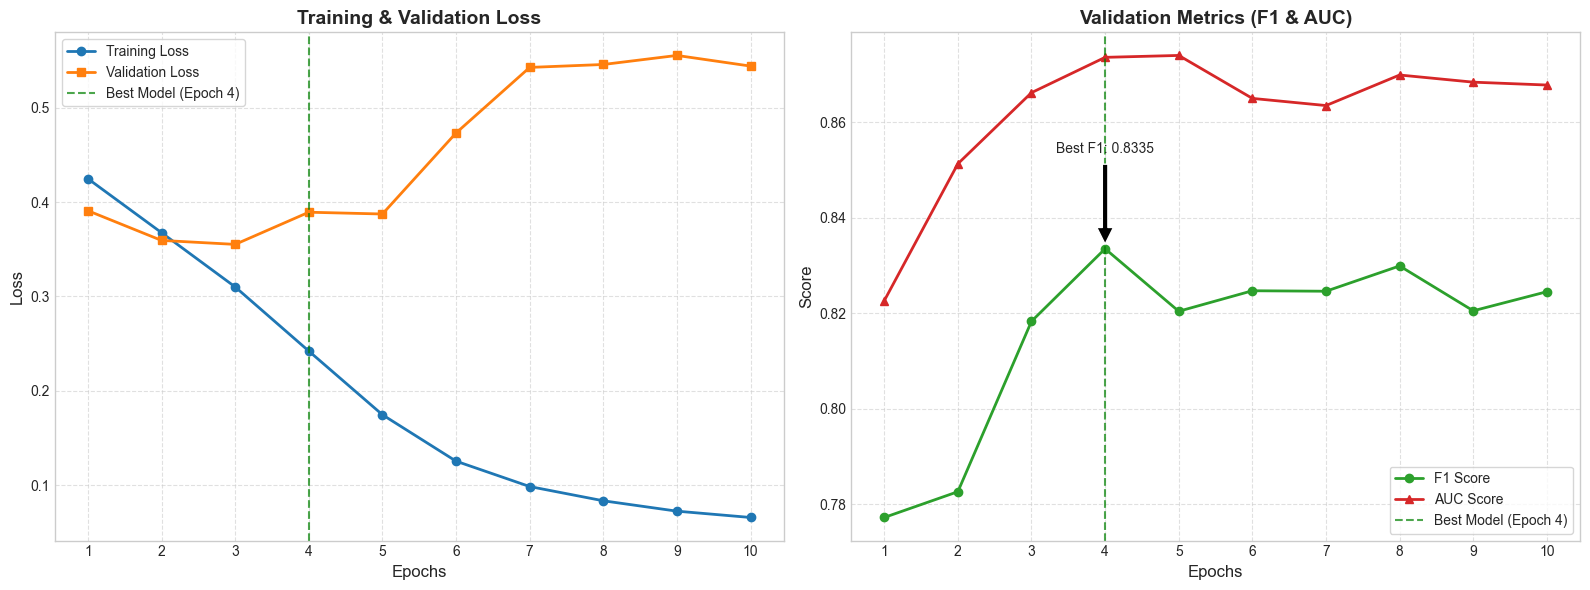

In [65]:
import matplotlib.pyplot as plt
import numpy as np

# Data Extraction
epochs = np.arange(1, 11)
train_loss = [0.4248, 0.3676, 0.3101, 0.2421, 0.1746, 0.1254, 0.0985, 0.0834, 0.0724, 0.0657]
val_loss = [0.3909, 0.3594, 0.3552, 0.3893, 0.3874, 0.4733, 0.5428, 0.5459, 0.5555, 0.5442]
f1_scores = [0.7772, 0.7826, 0.8183, 0.8335, 0.8204, 0.8247, 0.8246, 0.8299, 0.8205, 0.8245]
auc_scores = [0.8226, 0.8513, 0.8662, 0.8736, 0.8740, 0.8650, 0.8635, 0.8699, 0.8684, 0.8678]

# Best Epoch (Based on F1 Score logic from previous code)
best_epoch = 4

# Create Plot
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Loss
ax1.plot(epochs, train_loss, 'o-', label='Training Loss', color='#1f77b4', linewidth=2)
ax1.plot(epochs, val_loss, 's-', label='Validation Loss', color='#ff7f0e', linewidth=2)
ax1.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Model (Epoch {best_epoch})')
ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_xticks(epochs)
ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Metrics
ax2.plot(epochs, f1_scores, 'o-', label='F1 Score', color='#2ca02c', linewidth=2)
ax2.plot(epochs, auc_scores, '^-', label='AUC Score', color='#d62728', linewidth=2)
ax2.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Model (Epoch {best_epoch})')
ax2.set_title('Validation Metrics (F1 & AUC)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_xticks(epochs)
ax2.legend(loc='lower right', frameon=True)
ax2.grid(True, linestyle='--', alpha=0.6)

# Annotate Best Scores
best_f1 = f1_scores[best_epoch-1]
best_auc = auc_scores[best_epoch-1]
ax2.annotate(f'Best F1: {best_f1:.4f}', 
             xy=(best_epoch, best_f1), xytext=(best_epoch, best_f1+0.02),
             arrowprops=dict(facecolor='black', shrink=0.05), ha='center')

plt.tight_layout()
plt.show()

In [68]:
# --- CELL 7: WRAP & SAVE FULL CHECKPOINT ---
import os
import torch

# 1. Define Model Name (to match training)
MODEL_NAME = 'static' 

# 2. Point to the weights file saved by Cell 6
# (Ensure this matches what Cell 6 saved: "best_model.pth")
WEIGHTS_PATH = "best_model.pth" 
CHECKPOINT_PATH = "full_checkpoint.pth"

if os.path.exists(WEIGHTS_PATH):
    print(f"📦 Packaging best weights from '{WEIGHTS_PATH}' into a full checkpoint...")
    
    # 3. Load the best weights
    # Ensure 'model' architecture is defined (from Cell 6)
    model.load_state_dict(torch.load(WEIGHTS_PATH))
    model.eval()
    
    # 4. Re-calculate metrics
    print("   ⏳ Re-verifying metrics for the best model...")
    
    # --- FIX IS HERE: Removed the 4th argument (device) ---
    val_loss, val_acc, val_f1, val_auc = evaluate(model, val_loader, criterion)
    
    # 5. Create dictionary
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'config': CONFIG, # Saving the global CONFIG
        'metrics': {
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_f1': val_f1,
            'val_auc': val_auc
        }
    }
    
    # 6. Save
    torch.save(checkpoint, CHECKPOINT_PATH)
    print(f"✅ Full Checkpoint Saved to: {CHECKPOINT_PATH}")
    print(f"   🏆 Saved Metrics -> F1: {val_f1:.4f} | AUC: {val_auc:.4f} | Loss: {val_loss:.4f}")

else:
    print(f"❌ Error: '{WEIGHTS_PATH}' not found. Did training (Cell 6) finish successfully?")

📦 Packaging best weights from 'best_model.pth' into a full checkpoint...
   ⏳ Re-verifying metrics for the best model...
✅ Full Checkpoint Saved to: full_checkpoint.pth
   🏆 Saved Metrics -> F1: 0.8335 | AUC: 0.8736 | Loss: 0.3893
